# Chinese world — active individuals per year, with precision-based CI

Companion to `13_greek_polities_floruit.ipynb` and `13b_chinese_dynasties_floruit.ipynb`.

**Question.** How many individuals from the Chinese dynastic world were active in each calendar year?

**Why a confidence interval is needed.** Each individual in `individuals_floruit_period` carries a **floruit interval** `[start, end]` whose width reflects what we actually know about their dating:

- width 1 → a single year (`floruit` exact),
- width ≈ 25–26 → *decade* precision (derived from a known birth or death year, ± typical adult lifespan window),
- width ≈ 100 → *century* precision (the source only places the person in a given century).

Treating a century-precise individual as if they lived in a single year overstates per-year confidence; treating a year-precise individual as if they were spread over a century discards real signal.

**Model.** For each individual $i$ with floruit interval $[s_i, e_i]$ of width $w_i = e_i - s_i + 1$, the true year of activity $T_i$ is treated as uniformly distributed over $[s_i, e_i]$. The number of individuals active at year $y$ is

$$Y(y) = \sum_i \mathbb{1}[T_i = y], \qquad \Pr(T_i = y) = \frac{1}{w_i}\,\mathbb{1}[s_i \le y \le e_i].$$

Then

$$\mathbb{E}[Y(y)] = \sum_i \frac{1}{w_i}\,\mathbb{1}[s_i \le y \le e_i], \qquad \mathrm{Var}[Y(y)] = \sum_i \frac{1}{w_i}\!\left(1 - \frac{1}{w_i}\right)\mathbb{1}[s_i \le y \le e_i].$$

We plot the expected count and a 95 % normal-approximation band $\mathbb{E} \pm 1.96\sqrt{\mathrm{Var}}$. The band is narrow where many year-precise individuals dominate and widens where century-precise individuals dominate.

## 1. Configuration and imports

In [ ]:
# === notebook config ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = "../data/humans_clean.duckdb"

# Display window: Shang Dynasty start → end of Qing
YEAR_MIN, YEAR_MAX = -1600, 1912

# Precision palette (matches 13b)
COL_EXPECTED = '#2f5b8a'
COL_BAND     = '#9bbcd9'
COL_YEAR     = '#1f3a5f'
COL_DECADE   = '#4c78a8'
COL_CENTURY  = '#9bbcd9'
COL_NEUTRAL  = '#7f7f7f'

import matplotlib as _mpl
_mpl.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

In [ ]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Canonical Chinese dynasty list

Same canonical list of Chinese polities used in `13b_chinese_dynasties_floruit.ipynb` and `18_chinese_dynasties_identifiers.ipynb` — no invented groupings.

In [3]:
CHINESE_DYNASTIES = [
    'Shang Dynasty',
    'Zhou Dynasty',
    'Qin Dynasty',
    'Han Dynasty',
    'Xin Dynasty',
    'Western Jin',
    'Eastern Jin',
    'Liu Song Dynasty',
    'Liang Dynasty',
    'Chen Dynasty',
    'Northern Wei',
    'Eastern Wei',
    'Western Wei',
    'Northern Zhou',
    'Northern Qi',
    'Sui Dynasty',
    'Tang Dynasty',
    'Five Dynasties and Ten Kingdoms',
    'Northern Song',
    'Southern Song',
    'Liao Dynasty',
    'Western Xia',
    'Yuan Dynasty',
    'Ming Dynasty',
    'Qing Dynasty',
]
len(CHINESE_DYNASTIES), 'dynasties'

(25, 'dynasties')

## 3. Load Chinese individuals with a floruit interval

An individual is included if `polity_name` (semicolon list) contains *any* of the canonical dynasties **and** they appear in `individuals_floruit_period` with a non-null `floruit_period` and well-defined `[start, end]`. Each individual is counted **once** — no over-counting across dynasties.

In [ ]:
conn = duckdb.connect(DB_PATH, read_only=True)

like_clauses = ' OR '.join(["';' || ic.polity_name || ';' LIKE ?"] * len(CHINESE_DYNASTIES))
params = [f'%;{d};%' for d in CHINESE_DYNASTIES]

df = conn.execute(f"""
    SELECT DISTINCT ic.wikidata_id,
           fp.method,
           fp.floruit_period,
           fp.floruit_period_start AS s,
           fp.floruit_period_end   AS e
    FROM individuals_cliopatria ic
    JOIN individuals_floruit_period fp USING (wikidata_id)
    WHERE ({like_clauses})
      AND fp.floruit_period IS NOT NULL
      AND fp.floruit_period_start IS NOT NULL
      AND fp.floruit_period_end   IS NOT NULL
""", params).pl()
conn.close()

df = (
    df.with_columns(
        pl.col('s').cast(pl.Int64),
        pl.col('e').cast(pl.Int64),
    )
    .with_columns((pl.col('e') - pl.col('s') + 1).alias('width'))
    .filter(pl.col('width') >= 1)
    .unique(subset=['wikidata_id'])
)

# Clip to display window so a single 200-yr span doesn't drag the loop.
df = (
    df.filter((pl.col('e') >= YEAR_MIN) & (pl.col('s') <= YEAR_MAX))
    .with_columns(
        pl.col('s').clip(lower_bound=YEAR_MIN),
        pl.col('e').clip(upper_bound=YEAR_MAX),
    )
    .with_columns((pl.col('e') - pl.col('s') + 1).alias('width_eff'))
)

print(f'{df.height:,} unique Chinese individuals with a floruit interval')
print('Width distribution (top 6):')
print(df.group_by('width').agg(pl.len().alias('n')).sort('n', descending=True).head(6))

## 4. Classify precision

Three regimes drive the per-year uncertainty:

| Bucket | Width $w$ | Origin |
|---|---|---|
| year | 1 | exact `floruit` year |
| decade | 2 – 50 | derived from known birth/death year |
| century | > 50 | source places person in a given century |

In [ ]:
df = df.with_columns(
    pl.when(pl.col('width') <= 1).then(pl.lit('year'))
      .when(pl.col('width') <= 50).then(pl.lit('decade'))
      .otherwise(pl.lit('century'))
      .alias('precision')
)
df.group_by('precision').agg(pl.len().alias('n')).sort('precision')

## 5. Per-year expected count and variance

Vectorised accumulation over the full year axis. Each individual contributes $1/w_i$ to every year in $[s_i, e_i]$ for the expected count, and $\frac{1}{w_i}(1-\frac{1}{w_i})$ for the variance. The sums are computed with two `np.add.at` calls on a dense year axis.

In [ ]:
years = np.arange(YEAR_MIN, YEAR_MAX + 1)
n_years = len(years)

def per_year_stats(rows):
    """Return (expected, variance) arrays of length n_years.
    `rows` is a polars DataFrame with columns s, e, width_eff."""
    s = rows['s'].to_numpy()
    e = rows['e'].to_numpy()
    w = rows['width_eff'].to_numpy()
    p = 1.0 / w
    v = p * (1.0 - p)

    s_idx = s - YEAR_MIN
    e_idx = e - YEAR_MIN + 1

    delta_e = np.zeros(n_years + 1)
    delta_v = np.zeros(n_years + 1)
    np.add.at(delta_e, s_idx,  p)
    np.add.at(delta_e, e_idx, -p)
    np.add.at(delta_v, s_idx,  v)
    np.add.at(delta_v, e_idx, -v)

    expected = np.cumsum(delta_e)[:n_years]
    variance = np.clip(np.cumsum(delta_v)[:n_years], 0.0, None)  # clip FP roundoff (~1e-17 negatives)
    return expected, variance

expected, variance = per_year_stats(df)
se = np.sqrt(variance)
ci_low  = np.maximum(expected - 1.96 * se, 0.0)
ci_high = expected + 1.96 * se

by_prec = {p: per_year_stats(df.filter(pl.col('precision') == p))[0]
           for p in ['year', 'decade', 'century']}

stats_df = pl.DataFrame({
    'year': years,
    'expected': expected,
    'se': se,
    'ci_low': ci_low,
    'ci_high': ci_high,
    'n_year_prec':    by_prec['year'],
    'n_decade_prec':  by_prec['decade'],
    'n_century_prec': by_prec['century'],
})
stats_df.head()

## 6. Figure — active individuals per year with 95 % CI

In [ ]:
# Major Chinese eras (rough hull spans, sourced from polities_periods_cliopatria
# in 13b; here used only as visual era anchors)
ERAS = [
    ('Pre-imperial', YEAR_MIN, -221, '#efe9d8'),
    ('Han',          -206,      220, '#dde7f0'),
    ('Six Dynasties', 220,      589, '#e7dfe8'),
    ('Sui-Tang',      581,      907, '#dceadc'),
    ('Song-Yuan',     960,     1368, '#f3e2cf'),
    ('Ming',         1368,     1644, '#e2e2dd'),
    ('Qing',         1644,     1912, '#f0d8d8'),
]

def draw_eras(ax, ymax):
    for name, a, b, color in ERAS:
        a_clip, b_clip = max(a, YEAR_MIN), min(b, YEAR_MAX)
        if b_clip <= a_clip:
            continue
        ax.axvspan(a_clip, b_clip, color=color, alpha=0.55, zorder=0)
        ax.text((a_clip + b_clip) / 2, ymax * 1.02, name,
                ha='center', va='bottom', fontsize=11, color='#444')

fig, ax = plt.subplots(figsize=(13, 5.6))
ymax = float(ci_high.max()) * 1.02
draw_eras(ax, ymax)

ax.fill_between(years, ci_low, ci_high, color=COL_BAND, alpha=0.55,
                linewidth=0, label='95 % CI (precision uncertainty)', zorder=2)
ax.plot(years, expected, color=COL_EXPECTED, linewidth=1.4,
        label='Expected active individuals', zorder=3)

ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_ylim(0, ymax * 1.15)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Active individuals\n(expected, per year)')
ax.set_title('Chinese world — active individuals per year', loc='left',
             fontsize=15, pad=14)
ax.legend(loc='upper left', frameon=False)
ax.text(0.99, 0.95, f'N = {df.height:,} individuals',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='lightgray'))
fig.tight_layout()
plt.show()

## 7. Figure — stacked decomposition by precision

Same expected curve, decomposed into the contribution of year-, decade- and century-precise individuals so the source of the uncertainty band is visible.

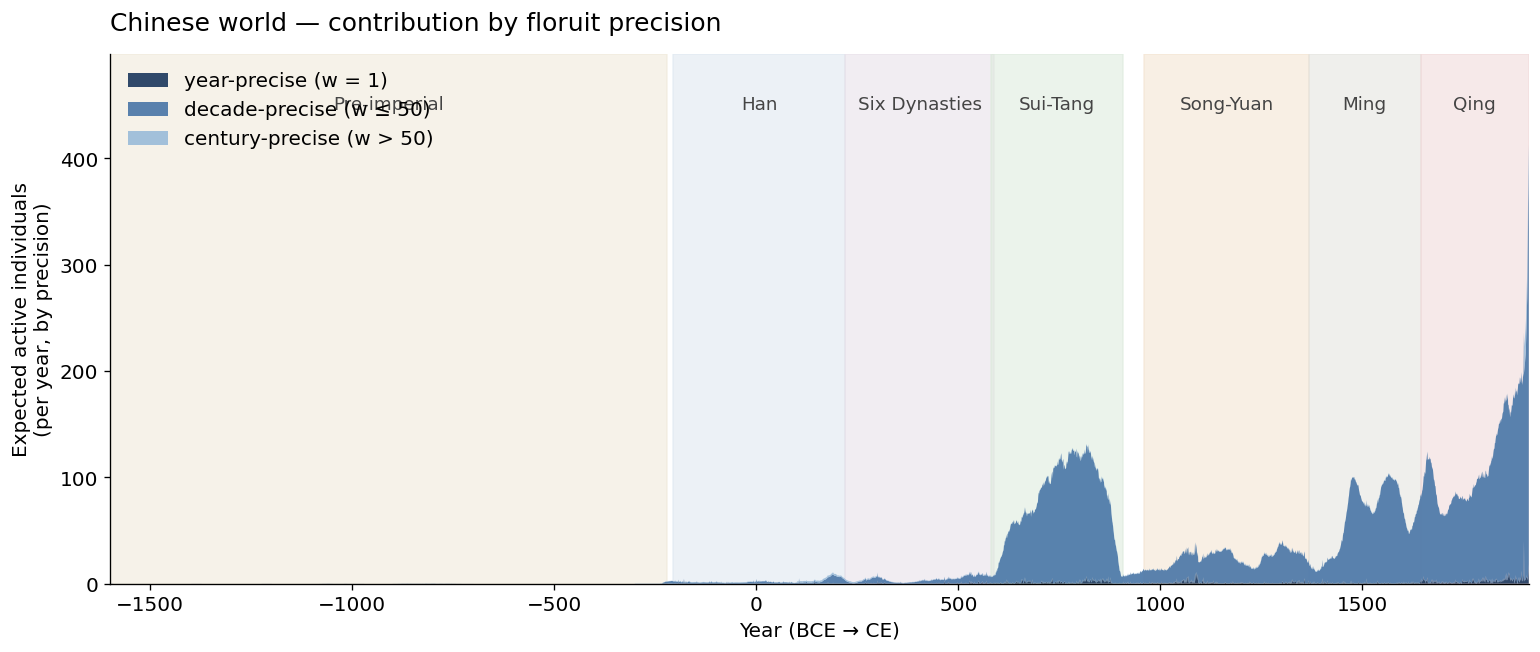

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.6))

ymax2 = float((by_prec['year'] + by_prec['decade'] + by_prec['century']).max()) * 1.05
draw_eras(ax, ymax2)

ax.stackplot(years,
             by_prec['year'], by_prec['decade'], by_prec['century'],
             colors=[COL_YEAR, COL_DECADE, COL_CENTURY],
             labels=['year-precise (w = 1)',
                     'decade-precise (w ≤ 50)',
                     'century-precise (w > 50)'],
             alpha=0.92, linewidth=0)

ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_ylim(0, ymax2 * 1.15)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Expected active individuals\n(per year, by precision)')
ax.set_title('Chinese world — contribution by floruit precision', loc='left',
             fontsize=15, pad=14)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
plt.show()

## 8. Monte-Carlo cross-check

Sanity check the analytical CI by simulating $K$ draws of the per-individual true year and recomputing the empirical 95 % envelope.

In [ ]:
K = 400  # Monte Carlo draws

rng = np.random.default_rng(SEED)
s_arr = df['s'].to_numpy()
e_arr = df['e'].to_numpy()
n_ind = df.height
counts = np.zeros((K, n_years), dtype=np.int32)

for k in tqdm(range(K), desc='MC draws'):
    sampled = rng.integers(s_arr, e_arr + 1)
    idx = sampled - YEAR_MIN
    np.add.at(counts[k], idx, 1)

mc_low  = np.percentile(counts, 2.5, axis=0)
mc_high = np.percentile(counts, 97.5, axis=0)
mc_mean = counts.mean(axis=0)

fig, ax = plt.subplots(figsize=(13, 5.2))
draw_eras(ax, float(max(ci_high.max(), mc_high.max())) * 1.02)
ax.fill_between(years, ci_low, ci_high, color=COL_BAND, alpha=0.45,
                linewidth=0, label='analytical 95 % CI')
ax.plot(years, expected, color=COL_EXPECTED, linewidth=1.3, label='analytical mean')
ax.plot(years, mc_low,  color=COL_NEUTRAL, linewidth=0.7, linestyle='--',
        label='Monte-Carlo 2.5 / 97.5 %')
ax.plot(years, mc_high, color=COL_NEUTRAL, linewidth=0.7, linestyle='--')
ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Active individuals (per year)')
ax.set_title('Analytical CI vs Monte-Carlo envelope', loc='left',
             fontsize=14, pad=10)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
plt.show()

## 9. Export per-year table

In [ ]:
out_path = '../data/chinese_world_yearly_ci.parquet'
stats_df.write_parquet(out_path)
print(f'wrote {out_path} ({stats_df.height:,} rows)')
stats_df.tail()